In [1]:
import datetime
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from src.datasource import YahooDataSource
from src.prediction import PredictionModeling
from src.bayesianopt import bayesianOpt
from src.riskmeasure import CumulativeReturn, ExponationalUtility, MeanSemiDeviation
from src.utils import buy_signal_plots, calculate_drawdown
from src.utils import find_cointegrated_pairs,get_top_k_pairs,get_cointergrated_coeff
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

c:\Users\aayus\Documents\GitHub\SpreadPrediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data Extraction

In [2]:
# Extract the Data from the Yahoo Data Source
start_date = datetime.datetime(2019, 3, 29)
end_date = datetime.datetime(2024, 3, 29)
tickers  =  ['SPY','AAPL','ADBE','EBAY','MSFT','QCOM',
                 'HPQ','JNPR','AMD','IBM','DAL','KO']
columns =   ["High","Close","Low","Volume"]
ds = YahooDataSource(start_date,end_date,tickers,columns)

In [3]:
# Get only Close column data
df_pair_search = ds.get_data_by_column_tickers(columns=["Close"],tickers=-1)

In [4]:
df_pair_search.head(n=5)
scores, pvalues, pairs = find_cointegrated_pairs(df_pair_search)

top_pairs = get_top_k_pairs(pairs,5)
print("Top pairs",top_pairs)

# Get first pair
tickers = ds.get_tickers(top_pairs[0][0])
print("Top ticker",tickers)

Top pairs [(('AMD_Close', 'MSFT_Close'), 0.018010366815767224)]
Top ticker ['AMD', 'MSFT']


In [5]:
first_series = 'MSFT_Close'
second_series =  'AMD_Close'

In [6]:
# Gather High, Low ,Close , Volume of selected stocks
columns = ["High","Close","Low","Volume"]
df_raw = ds.get_data_by_column_tickers(columns=columns,tickers=tickers)

In [7]:
df_raw

,AMD_Volume,AMD_Low,AMD_High,AMD_Close,MSFT_Volume,MSFT_Low,MSFT_High,MSFT_Close
0,53502800,25.250000,25.730000,25.520000,25399800,110.287310,111.569721,111.211403
1,63000300,25.830000,26.559999,26.360001,22789100,111.362271,112.314651,112.229782
2,53358800,26.090000,26.799999,26.750000,18142300,111.758287,112.663524,112.390068
3,197650500,27.879999,29.950001,29.020000,22860700,112.352362,113.559335,113.125580
4,82191100,28.610001,29.389999,29.090000,20112800,111.626314,113.370776,112.550407
...,...,...,...,...,...,...,...,...
1254,57899100,175.050003,180.759995,179.649994,17648500,422.066955,425.821325,424.711853
1255,71935300,172.000000,182.800003,178.630005,18060500,417.648768,423.394293,418.887024
1256,65322400,176.330002,182.600006,177.869995,16725600,417.391246,421.987636,417.688416
1257,55685600,175.399994,181.229996,179.589996,16705000,415.073243,420.462135,417.470490


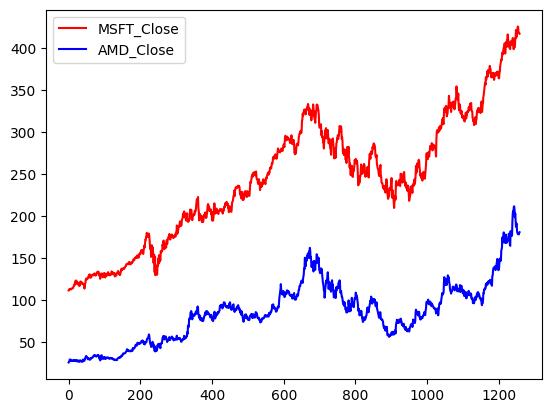

In [8]:
plt.plot(df_raw[first_series],color='r')
plt.plot(df_raw[second_series],color='b')
plt.legend([f'{first_series}',f'{second_series}'])

In [9]:
# Find ratio between co-integrated pairs
coeff = get_cointergrated_coeff(df_raw[first_series],df_raw[second_series])
print(coeff)

-1.9361831161579068


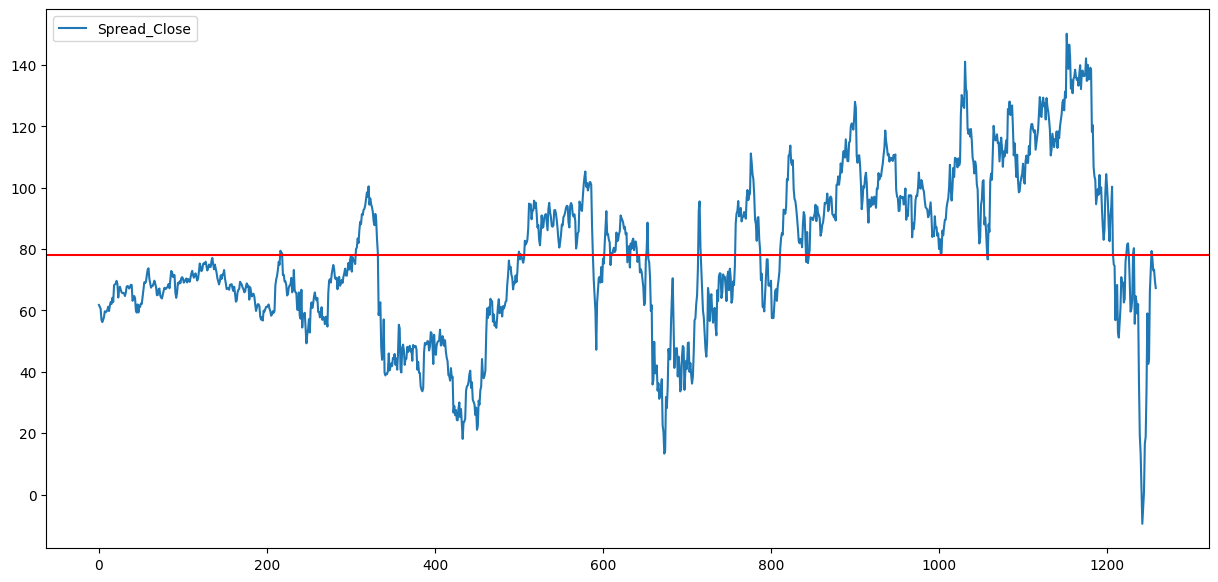

In [10]:
df_raw['Spread_Close'] = df_raw[first_series] + (df_raw[second_series] * coeff)
df_raw['Spread_Close'].plot(figsize=(15,7))
plt.axhline(df_raw['Spread_Close'].mean(),c='red')
plt.legend(['Spread_Close'])

In [11]:
pm = PredictionModeling(df_raw,"Spread_Close",0.60,1)

In [12]:
pm.add_arima_forecast("Spread_Close",order=(1,1,0))

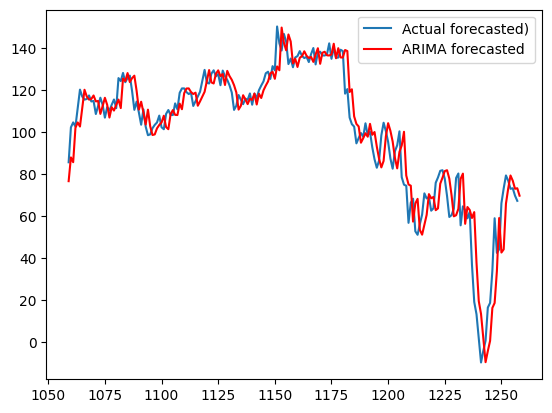

In [13]:
plt.plot(pm.data["Spread_Close_Actual_value_fore_perod_1"][-200:])
plt.plot(pm.data["Spread_Close_ARIMA_forecast_1"][-200:],color='r')
plt.legend(["Actual forecasted)","ARIMA forecasted"])

In [14]:
pm.data

,AMD_Volume,AMD_Low,AMD_High,AMD_Close,MSFT_Volume,MSFT_Low,MSFT_High,MSFT_Close,Spread_Close,Spread_Close_Actual_fore_perod_1,Spread_Close_Actual_value_fore_perod_1,Spread_Close_Actual_mean_fore_perod_1,Spread_Close_ARIMA_forecast_1,Spread_Close_ARIMA_forecasts_1
0,53502800,25.250000,25.730000,25.520000,25399800,110.287310,111.569721,111.211403,61.800009,[61.19199398081737],61.191994,61.191994,NaN,NaN
1,63000300,25.830000,26.559999,26.360001,22789100,111.362271,112.314651,112.229782,61.191994,[60.59716969697521],60.597170,60.597170,NaN,NaN
2,53358800,26.090000,26.799999,26.750000,18142300,111.758287,112.663524,112.390068,60.597170,[56.93754491676763],56.937545,56.937545,NaN,NaN
3,197650500,27.879999,29.950001,29.020000,22860700,112.352362,113.559335,113.125580,56.937545,[56.22684026519636],56.226840,56.226840,NaN,NaN
4,82191100,28.610001,29.389999,29.090000,20112800,111.626314,113.370776,112.550407,56.226840,[56.93956981970659],56.939570,56.939570,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1254,57899100,175.050003,180.759995,179.649994,17648500,422.066955,425.821325,424.711853,76.876568,[73.02662443247522],73.026624,73.026624,79.360728,[79.36072813312384]
1255,71935300,172.000000,182.800003,178.630005,18060500,417.648768,423.394293,418.887024,73.026624,[73.29953411035598],73.299534,73.299534,76.885134,[76.88513405567802]
1256,65322400,176.330002,182.600006,177.869995,16725600,417.391246,421.987636,417.688416,73.299534,[69.75137076166897],69.751371,69.751371,73.038609,[73.03860944426002]
1257,55685600,175.399994,181.229996,179.589996,16705000,415.073243,420.462135,417.470490,69.751371,[67.30544960779412],67.305450,67.305450,73.298676,[73.29867572479127]


In [15]:
pm.data[:907]

,AMD_Volume,AMD_Low,AMD_High,AMD_Close,MSFT_Volume,MSFT_Low,MSFT_High,MSFT_Close,Spread_Close,Spread_Close_Actual_fore_perod_1,Spread_Close_Actual_value_fore_perod_1,Spread_Close_Actual_mean_fore_perod_1,Spread_Close_ARIMA_forecast_1,Spread_Close_ARIMA_forecasts_1
0,53502800,25.250000,25.730000,25.520000,25399800,110.287310,111.569721,111.211403,61.800009,[61.19199398081737],61.191994,61.191994,NaN,NaN
1,63000300,25.830000,26.559999,26.360001,22789100,111.362271,112.314651,112.229782,61.191994,[60.59716969697521],60.597170,60.597170,NaN,NaN
2,53358800,26.090000,26.799999,26.750000,18142300,111.758287,112.663524,112.390068,60.597170,[56.93754491676763],56.937545,56.937545,NaN,NaN
3,197650500,27.879999,29.950001,29.020000,22860700,112.352362,113.559335,113.125580,56.937545,[56.22684026519636],56.226840,56.226840,NaN,NaN
4,82191100,28.610001,29.389999,29.090000,20112800,111.626314,113.370776,112.550407,56.226840,[56.93956981970659],56.939570,56.939570,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
902,79761600,59.150002,61.770000,59.730000,82543200,224.844892,232.898110,226.076340,110.428123,[108.14958140514483],108.149581,108.149581,125.983875,[125.98387506917639]
903,83871400,58.509998,62.720001,58.599998,40424600,220.661896,228.392592,221.609909,108.149581,[110.46045105866415],110.460451,110.460451,110.576474,[110.57647430585163]
904,78198600,58.919998,62.349998,62.009998,40647700,220.925776,231.236626,230.523163,110.460451,[110.58078982406636],110.580790,110.580790,108.166424,[108.16642388590526]
905,73274100,59.529999,61.860001,60.060001,28357300,225.910155,229.594699,226.867950,110.580790,[107.48504202588707],107.485042,107.485042,110.442678,[110.44267800220746]


# Data Prepareation of Hyperparameter Tuning for Trading Strategy

In [16]:
total_length =(len(pm.data) - pm.train_end_index)-1
train_size = 0.70
length_param_training = int((len(pm.data) - pm.train_end_index)*0.70)

In [17]:
test_data = pm.data[[first_series,second_series,"Spread_Close","Spread_Close_Actual_value_fore_perod_1","Spread_Close_ARIMA_forecast_1"]][pm.train_end_index:-1]

In [18]:

spread_ARIMA_val = test_data["Spread_Close_ARIMA_forecast_1"][:length_param_training]
S1_val = test_data[first_series][:length_param_training]
S2_val = test_data[second_series][:length_param_training]

spread_ARIMA_test = test_data["Spread_Close_ARIMA_forecast_1"][length_param_training:]

S1_test = test_data[first_series][length_param_training:]
S2_test = test_data[second_series][length_param_training:]

In [135]:
45*4000*6

1080000

# Define set of Hyper parameters

In [75]:
sell_treshold_params = np.linspace(0.4,3,5)
buy_threshold_params = np.linspace(-0.4,-3,5)
clear_threshold_params = np.linspace(0,0.3,5)
window1_param = np.arange(30,100,10)
window2_param = np.arange(1,14,3)
window_param = list(zip(window1_param,window2_param))

param_grid = { 'window1':window1_param,
              'window2':window2_param,
              "sell_threshold":sell_treshold_params,
              "buy_threshold":buy_threshold_params,
              "clear_threshold":clear_threshold_params }
config_dict = {"num_iteration":800}

In [76]:
buy_threshold_params


array([-0.4 , -1.05, -1.7 , -2.35, -3.  ])

# Trading Strategy using Trading Strategy using ARIMA

In [77]:

cumilative_return = CumulativeReturn()
byopt =  bayesianOpt(cumilative_return)

In [78]:
params = byopt.optimize(coeff,spread_ARIMA_val,S1_val,S2_val,param_grid,config_dict)
print(byopt.optimize_results["best_params"])
window1 = byopt.optimize_results["best_params"]["window1"]
window2 = byopt.optimize_results["best_params"]["window2"]
sell_threshold = byopt.optimize_results["best_params"]["sell_threshold"]
buy_threshold = byopt.optimize_results["best_params"]["buy_threshold"]
clear_threshold = byopt.optimize_results["best_params"]["clear_threshold"]

Best score: 82552.27822201586:  60%|█████▉    | 479/800 [04:40<03:07,  1.71it/s]


KeyboardInterrupt: 

In [ ]:
#byopt.optimize_results["best_params"] = {'buy_threshold': -3.0, 'clear_threshold': 0.0, 'sell_threshold': 0.5368421052631579, 'window1': 57, 'window2': 7}

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 488.21419988074354, 971.4702626650475, 1457.5430559303695, 1944.097754090249, 2441.4348872305018, 2934.520779371198, 3426.2911875028985, 3908.3496063336415, 4396.765456562642, 4894.377073892479, 5400.246884136554, 5901.980649447678, 6404.381689180092, 6901.958339251884, 7408.142091785709, 7917.921800617172, 8424.882453900509, 8930.381164060193, 9433.691169133139, 9938.385615376115, 10440.658726162257, 10937.191026979406, 11430.815836219808, 11921.108617373045, 12411.86756820086, 12907.140945552343, 13407.037792750174, 13908.52277411041, 13908.52277411041, 13908.52277411041, 13908.52277411041, 13908.52277411041, 13908.52277411041, 13908.52277411041, 13908.52277411041, 13908.52277411041, 13908.52277411041, 13908.522

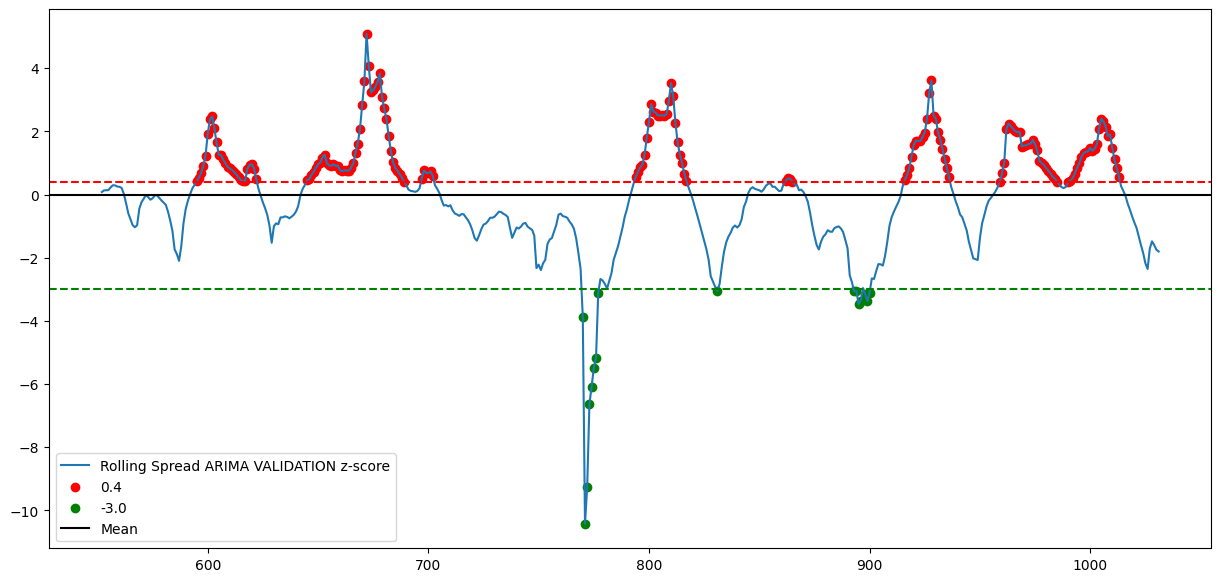

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 533.5258412778488, 1057.2274541184024, 1572.1311136824906, 2088.5956542378144, 2615.752013060834, 3138.524013458499, 3673.0754286907695, 4185.916729828313, 4702.599522303115, 5220.689791100236, 5220.689791100236, 5220.689791100236, 5220.689791100236, 5220.689791100236, 5220.689791100236, 5220.689791100236, 5220.689791100236, 5220.689791100236, 5220.689791100236, 5220.689791100236, 5220.689791100236, 5220.689791100236, 5220.689791100236, 5220.689791100236, 5220.689791100236, 5220.689791100236, 5220.689791100236, 5220.689791100236, 5220.689791100236, 4726.882216954555, 4228.3479073125745, 4228.3479073125745, 4228.3479073125745, 4228.3479073125745, 4228.3479073125745, 4228.3479073125745, 4228.3479073125745, 4228.3479073125745, 4228.3479073125745, 4228.3479073125745, 4228.3479073125

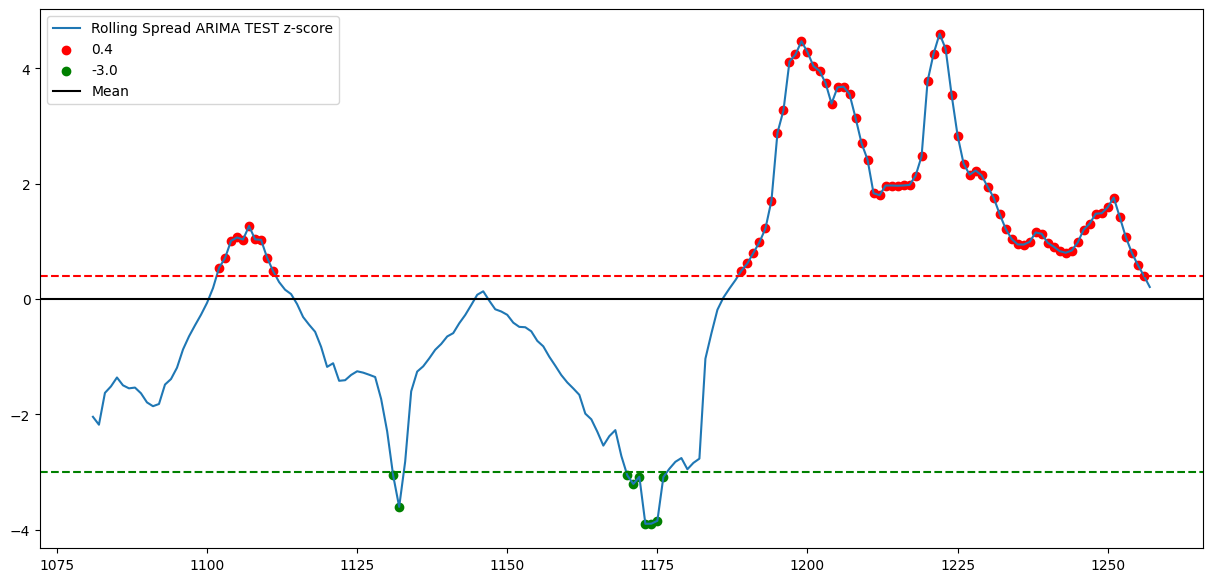

Optimal Parameters {'window2': 13, 'window1': 50, 'sell_threshold': 0.4, 'clear_threshold': 0.0, 'buy_threshold': -3.0}
Money on validation data 79366.0879636797
Money on test data 49318.55543836449


In [27]:
money_val = byopt.trade(S1_val,S2_val,spread_ARIMA_val,coeff,window1, window2,sell_threshold,buy_threshold,clear_threshold)
print(money_val)
buy_signal_plots(spread_ARIMA_val,S1_val,S2_val,window1,window2,sell_threshold,buy_threshold,label="ARIMA VALIDATION")

money_test = byopt.trade(S1_test,S2_test,spread_ARIMA_test,coeff,window1, window2,sell_threshold,buy_threshold,clear_threshold)
print(money_test)
buy_signal_plots(spread_ARIMA_test,S1_test,S2_test,window1,window2,sell_threshold,buy_threshold,label="ARIMA TEST")


print("Optimal Parameters",byopt.optimize_results["best_params"])
print("Money on validation data",money_val[-1])
print("Money on test data",money_test[-1])

In [28]:
exponational_risk = ExponationalUtility(0.006)
byopt_exp =  bayesianOpt(exponational_risk)
params_exp = byopt_exp.optimize(coeff,spread_ARIMA_val,S1_val,S2_val,param_grid,config_dict)
print(byopt_exp.optimize_results["best_params"])
window1_exp = byopt_exp.optimize_results["best_params"]["window1"]
window2_exp = byopt_exp.optimize_results["best_params"]["window2"]
sell_threshold_exp = byopt_exp.optimize_results["best_params"]["sell_threshold"]
buy_threshold_exp = byopt_exp.optimize_results["best_params"]["buy_threshold"]
clear_threshold_exp = byopt_exp.optimize_results["best_params"]["clear_threshold"]


Best score: -0.17969820741525444: 100%|██████████| 400/400 [01:35<00:00,  4.18it/s]

{'buy_threshold': -2.35, 'clear_threshold': 0.075, 'sell_threshold': 0.4, 'window1': 60, 'window2': 13}


In [29]:

from abc import ABC, abstractmethod
import numpy as np
import pandas as pd



class RiskMeasure(ABC):

    @abstractmethod
    def calculate(self, money_arr):
        pass


In [80]:
class MeanSemiDeviation(RiskMeasure):

    def __init__(self,chi=0.3):
        self.chi = chi

    def calculate(self, money_arr):
        """
        Calcilate the mean semi deviation of a money array"
        rho = E[loss] + chi*E[[E[loss]-loss]_+]
        """
        # Calculate loss returns 
   
        money_arr_arr = np.array(money_arr)

        # Calculate returns
        returns = np.diff(money_arr_arr) / money_arr_arr[:-1]
        # Fill NaN values with 0
        returns = np.nan_to_num(returns)

        # Calculate losses
        

        # Calculate mean and semi-deviation
        mean_returns = np.mean(returns)
        semi_deviation = np.mean(np.maximum(returns-mean_returns, 0))

        return mean_returns - self.chi*semi_deviation


class Drawdown(RiskMeasure):

    def __init__(self, chi=0.4):
        self.chi = chi

    # def calculate(self, money_arr):
    #     """
    #     Calculate the drawdown of a money array
    #     """
    #     # Convert to numpy array
    #     money_arr = np.array(money_arr)
        
    #    # Calculate drawdown
    #     money_diff = np.minimum(np.diff(money_arr)[1:],0)

    #     return money_arr[-1] + 8*np.sum(money_diff)
    
    def calculate(self, money_arr):
        """
        Calculate the drawdown of a money array
        """
        # Convert to numpy array
        money_arr = np.array(money_arr)

        # Calculate returns
        money_diff_rtn = np.diff(money_arr)

        # Fill NaN values with 0
        money_diff_rtn = np.nan_to_num(money_diff_rtn)
        
       # Calculate drawdown
        money_diff_rtn_dv = np.minimum(money_diff_rtn,np.mean(money_diff_rtn))

        return (1-self.chi)*np.sum(money_diff_rtn) + self.chi*np.sum(money_diff_rtn_dv)
    

    

    class MeanSemiDeviation(RiskMeasure):

        def __init__(self, chi=0.3):
            self.chi = chi

        def calculate(self, money_arr):
            """
            Calculate the mean semi deviation of a money array
            """
            # Convert to numpy array
            money_arr = np.array(money_arr)

            # Calculate returns
            diff = np.diff(money_arr)
            # Fill NaN values with 0
            diff = np.nan_to_num(diff)

            # Calculate 
            mean_diff = np.mean(diff)
            semi_deviation = np.mean(np.minimum(diff-mean_diff, 0))

            return mean_diff + self.chi * semi_deviation

In [81]:
mean_semi_deviation = Drawdown(chi=0.8)
byopt_msd =  bayesianOpt(mean_semi_deviation)
params_msd = byopt_msd.optimize(coeff,spread_ARIMA_val,S1_val,S2_val,param_grid,config_dict)
print(byopt_msd.optimize_results["best_params"])
window1_msd = byopt_msd.optimize_results["best_params"]["window1"]
window2_msd = byopt_msd.optimize_results["best_params"]["window2"]
sell_threshold_msd = byopt_msd.optimize_results["best_params"]["sell_threshold"]    
buy_threshold_msd = byopt_msd.optimize_results["best_params"]["buy_threshold"]
clear_threshold_msd = byopt_msd.optimize_results["best_params"]["clear_threshold"]
print("Optimal Parameters",byopt_msd.optimize_results["best_params"])

Best score: 32318.05317499273: 100%|██████████| 800/800 [1:10:45<00:00,  5.31s/it]  

{'buy_threshold': -3.0, 'clear_threshold': 0.0, 'sell_threshold': 0.4, 'window1': 50, 'window2': 13}
Optimal Parameters {'buy_threshold': -3.0, 'clear_threshold': 0.0, 'sell_threshold': 0.4, 'window1': 50, 'window2': 13}


In [57]:
mean_semi_deviation = MeanSemiDeviation(chi=0.2)
byopt_msd =  bayesianOpt(mean_semi_deviation)
params_msd = byopt_msd.optimize(coeff,spread_ARIMA_val,S1_val,S2_val,param_grid,config_dict)
print(byopt_msd.optimize_results["best_params"])
window1_msd = byopt_msd.optimize_results["best_params"]["window1"]
window2_msd = byopt_msd.optimize_results["best_params"]["window2"]
sell_threshold_msd = byopt_msd.optimize_results["best_params"]["sell_threshold"]    
buy_threshold_msd = byopt_msd.optimize_results["best_params"]["buy_threshold"]
clear_threshold_msd = byopt_msd.optimize_results["best_params"]["clear_threshold"]
print("Optimal Parameters",byopt_msd.optimize_results["best_params"])

Best score: 3.1912233895297817: 100%|██████████| 400/400 [01:55<00:00,  3.47it/s]

{'buy_threshold': -2.35, 'clear_threshold': 0.3, 'sell_threshold': 1.7000000000000002, 'window1': 40, 'window2': 4}
Optimal Parameters {'buy_threshold': -2.35, 'clear_threshold': 0.3, 'sell_threshold': 1.7000000000000002, 'window1': 40, 'window2': 4}


In [35]:
{'buy_threshold': -3.0, 'clear_threshold': 0.0, 'sell_threshold': 0.6736842105263159, 'window1': 23, 'window2': 12}

{'buy_threshold': -3.0,
 'clear_threshold': 0.0,
 'sell_threshold': 0.6736842105263159,
 'window1': 23,
 'window2': 12}

In [ ]:
e

In [34]:
rd_window_1 = 65
rd_window_2 = 10
rd_sell_threshold = 1
rd_buy_threshold = -2
rd_clear_threshold = 0

# Optimal Parameters {'buy_threshold': -3.0, 'clear_threshold': 0.0, 'sell_threshold': 0.5368421052631579, 'window1': 65, 'window2': 12}
# Money on validation data 75911.82971778436
# Money on test data 38066.41664118262

In [82]:
money_val_rd = bayesianOpt.trade(S1_val,S2_val,spread_ARIMA_val,coeff,rd_window_1,rd_window_2,rd_sell_threshold,rd_buy_threshold,rd_clear_threshold)
money_val_opt = bayesianOpt.trade(S1_val,S2_val,spread_ARIMA_val,coeff,window1, window2,sell_threshold,buy_threshold,clear_threshold)
money_val_exp_opt = bayesianOpt.trade(S1_val,S2_val,spread_ARIMA_val,coeff,window1_exp, window2_exp,sell_threshold_exp,buy_threshold_exp,clear_threshold_exp)
money_val_msd_opt = bayesianOpt.trade(S1_val,S2_val,spread_ARIMA_val,coeff,window1_msd, window2_msd,sell_threshold_msd,buy_threshold_msd,clear_threshold_msd)

In [83]:


money_arr = np.array(money_val_exp_opt)

        # Calculate returns
money_diff_rtn = np.diff(money_arr)/ money_arr[:-1]

# Fill NaN values with 0
money_diff_rtn = np.nan_to_num(money_diff_rtn)

# Calculate drawdown
money_diff_rtn_dv = np.minimum(money_diff_rtn,0)

print(np.sum(money_diff_rtn) + 0.000*np.sum(money_diff_rtn_dv))


495.99708521243474


In [84]:
pd.Series(money_diff_rtn).to_csv("money_diff_rtn_xp.csv")

In [85]:
np.sum(np.minimum(np.diff(money_val_exp_opt),0))

-89129.01536520413

In [86]:
# Calculate Exponational Utility

def utility(risk_aversion,money_arr):
    return -1*np.mean(np.exp(-risk_aversion *np.array(money_arr)))

print("Risk Aversion Utility rd",utility(0.009,money_val_rd))
print("Risk Aversion Utility opt",utility(0.009,money_val_opt))
print("Risk Aversion Utility exp",utility(0.009,money_val_exp_opt))
print("Risk Aversion Utility msd",utility(0.009,money_val_msd_opt))


Risk Aversion Utility rd -16463630.918122364
Risk Aversion Utility opt -0.17270497828808234
Risk Aversion Utility exp -0.17504797239251288
Risk Aversion Utility msd -0.17270497828808234


In [87]:
money_val_opt

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 488.21419988074354,
 971.4702626650475,
 1457.5430559303695,
 1944.097754090249,
 2441.4348872305018,
 2934.520779371198,
 3426.2911875028985,
 3908.3496063336415,
 4396.765456562642,
 4894.377073892479,
 5400.246884136554,
 5901.980649447678,
 6404.381689180092,
 6901.958339251884,
 7408.142091785709,
 7917.921800617172,
 8424.882453900509,
 8930.381164060193,
 9433.691169133139,
 9938.385615376115,
 10440.658726162257,
 10937.191026979406,
 11430.815836219808,
 11921.108617373045,
 12411.86756820086,
 12907.140945552343,
 13407.037792750174,
 13908.52277411041,
 13908.52277411041,
 13908.52277411041,
 13908.52277411041,
 

In [88]:
money_val_opt

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 488.21419988074354,
 971.4702626650475,
 1457.5430559303695,
 1944.097754090249,
 2441.4348872305018,
 2934.520779371198,
 3426.2911875028985,
 3908.3496063336415,
 4396.765456562642,
 4894.377073892479,
 5400.246884136554,
 5901.980649447678,
 6404.381689180092,
 6901.958339251884,
 7408.142091785709,
 7917.921800617172,
 8424.882453900509,
 8930.381164060193,
 9433.691169133139,
 9938.385615376115,
 10440.658726162257,
 10937.191026979406,
 11430.815836219808,
 11921.108617373045,
 12411.86756820086,
 12907.140945552343,
 13407.037792750174,
 13908.52277411041,
 13908.52277411041,
 13908.52277411041,
 13908.52277411041,
 

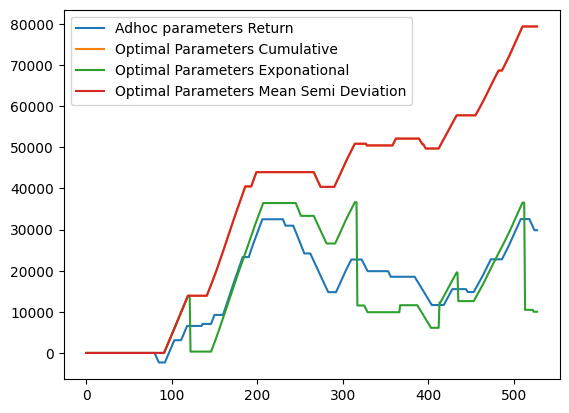

In [89]:
plt.plot(money_val_rd)
plt.plot(money_val_opt)
plt.plot(money_val_exp_opt)
plt.plot(money_val_msd_opt)
plt.legend(["Adhoc parameters Return","Optimal Parameters Cumulative","Optimal Parameters Exponational","Optimal Parameters Mean Semi Deviation"])

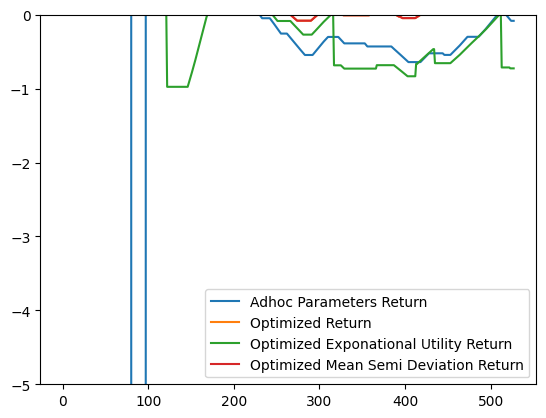

In [90]:
plt.plot(calculate_drawdown(money_val_rd),label="Adhoc Parameters Return")
plt.plot(calculate_drawdown(money_val_opt),label="Optimized Return")
plt.plot(calculate_drawdown(money_val_exp_opt),label="Optimized Exponational Utility Return")
plt.plot(calculate_drawdown(money_val_msd_opt),label="Optimized Mean Semi Deviation Return")
plt.ylim([-5,0])
plt.legend()


In [91]:
val_drawdown = np.min(calculate_drawdown(money_val_rd))
val_opt_drawdown = np.min(calculate_drawdown(money_val_opt))
val_exp_drawdown = np.min(calculate_drawdown(money_val_exp_opt))

print("Val drawdown",val_drawdown)
print("Val optimized drawdown",val_opt_drawdown)
print("Val optimized exponational drawdown",val_exp_drawdown)
print("Val optimized mean semi deviation drawdown",np.min(calculate_drawdown(money_val_msd_opt)))


Val drawdown -2312.0
Val optimized drawdown -0.08149058149058148
Val optimized exponational drawdown -0.9759850445786598
Val optimized mean semi deviation drawdown -0.08149058149058148


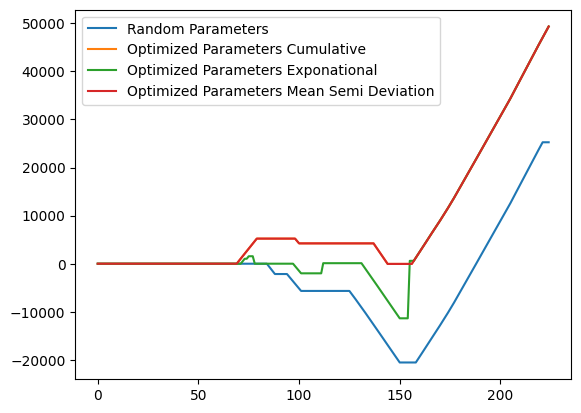

In [92]:
money_test_rd = bayesianOpt.trade(S1_test,S2_test,spread_ARIMA_test,coeff,rd_window_1,rd_window_2,rd_sell_threshold,rd_buy_threshold,rd_clear_threshold)
money_test_opt = bayesianOpt.trade(S1_test,S2_test,spread_ARIMA_test,coeff,window1, window2,sell_threshold,buy_threshold,clear_threshold)
money_test_exp_opt = bayesianOpt.trade(S1_test,S2_test,spread_ARIMA_test,coeff,window1_exp, window2_exp,sell_threshold_exp,buy_threshold_exp,clear_threshold_exp)
money_test_msd_opt = bayesianOpt.trade(S1_test,S2_test,spread_ARIMA_test,coeff,window1_msd, window2_msd,sell_threshold_msd,buy_threshold_msd,clear_threshold_msd)
plt.plot(money_test_rd)
plt.plot(money_test_opt)
plt.plot(money_test_exp_opt)
plt.plot(money_test_msd_opt)
plt.legend(["Random Parameters","Optimized Parameters Cumulative","Optimized Parameters Exponational","Optimized Parameters Mean Semi Deviation"])

In [76]:
print("Money gain using random parameters",money_test_rd[-1])
print("Money gain using optimized parameters",money_test_opt[-1])
print("Money gain using optimized parameters exponational",money_test_exp_opt[-1])

print("Performance gain over benchmark Cumilative  ",(money_test_opt[-1]- money_test_rd[-1])/money_test_rd[-1])

print("Performance gain over benchmark exponational",(money_test_exp_opt[-1]- money_test_rd[-1])/money_test_rd[-1])


Money gain using random parameters 25249.96554526703
Money gain using optimized parameters 39495.02220069581
Money gain using optimized parameters exponational 49318.555580741624
Performance gain over benchmark Cumilative   0.5641614294439675
Performance gain over benchmark exponational 0.9532127872541244


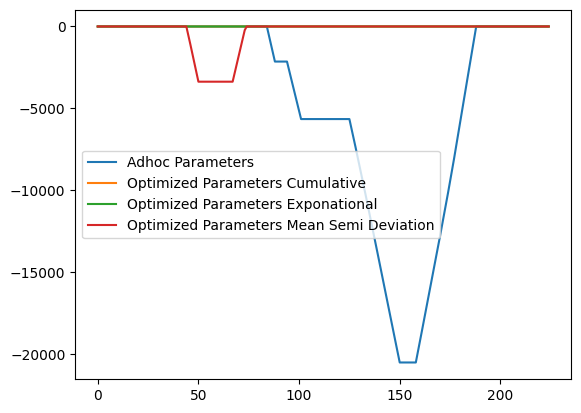

In [77]:
plt.plot(calculate_drawdown(money_test_rd),label="Adhoc Parameters")
plt.plot(calculate_drawdown(money_test_opt),label="Optimized Parameters Cumulative")
plt.plot(calculate_drawdown(money_test_exp_opt),label="Optimized Parameters Exponational")
plt.plot(calculate_drawdown(money_test_msd_opt),label="Optimized Parameters Mean Semi Deviation")
# plt.ylim(-1,0)
plt.legend()

In [84]:
val_test_rd = calculate_drawdown(money_test_rd)
val_test_opt = calculate_drawdown(money_test_opt)
val_test_exp_op = calculate_drawdown(money_test_exp_opt)
val_test_msd_op = calculate_drawdown(money_test_msd_opt)

print("Test drawdown",np.min(val_test_rd))
print("Test optimized drawdown",np.min(val_test_opt))
print("Test optimized drawdown",np.min(val_test_exp_op))
print("Test optimized mean semi deviation drawdown",np.min(val_test_msd_op))

#Reduction in drawdown
print("Reduction in drawdown Cumilative  ",(np.min(val_test_rd)-np.min(val_test_opt))/np.min(val_test_rd))
print("Reduction in drawdown Exponational  ",(np.min(val_test_rd)-np.min(val_test_exp_op))/np.min(val_test_rd))
print("Reduction in drawdown Mean Semi Deviation  ",(np.min(val_test_rd)-np.min(val_test_msd_op))/np.min(val_test_rd))





Test drawdown -20533.0
Test optimized drawdown -3.9404079031230084
Test optimized drawdown -5025.0
Test optimized mean semi deviation drawdown -1.007854406130268
Reduction in drawdown Cumilative   0.9998080939023464
Reduction in drawdown Exponational   0.7552720011688502
Reduction in drawdown Mean Semi Deviation   0.9999509153846915


In [78]:
# Calculate sharpe from wealth
def sharpe_ratio(wealth):
    daily_returns = np.diff(wealth) / wealth[:-1]
    return (np.mean(daily_returns) / np.std(daily_returns))*np.sqrt(252)

# Calculate sharpe ratio on test data
sharpe_rd = sharpe_ratio(money_test_rd)
sharpe_opt = sharpe_ratio(money_test_opt)
sharpe_exp = sharpe_ratio(money_test_exp_opt)
sharpe_msd = sharpe_ratio(money_test_msd_opt)

print("Sharpe Ratio Random Parameters",sharpe_rd)
print("Sharpe Ratio Optimized Parameters",sharpe_opt)
print("Sharpe Ratio Optimized Parameters Exponational",sharpe_exp)
print("Sharpe Ratio Optimized Parameters Mean Semi Deviation",sharpe_msd)

Sharpe Ratio Random Parameters -0.9430040091396877
Sharpe Ratio Optimized Parameters 1.0755183673672923
Sharpe Ratio Optimized Parameters Exponational 1.041649485606468
Sharpe Ratio Optimized Parameters Mean Semi Deviation -1.0542017825842942


In [65]:
len(money_val_rd)

528

In [ ]:
# Calculate average drawdowns
def average_drawdown(wealth):
    daily_returns = np.diff(wealth) / wealth[:-1]
    drawdowns = (np.maximum.accumulate(daily_returns) - daily_returns)
    return np.mean(drawdowns)

In [67]:
# calculate returns from portfolio wealth using numpy 
np.diff(money_val_rd)/money_val_rd[:-1]

array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  

In [64]:
# Calculate sharpe on validation data
sharpe_val_rd = sharpe_ratio(money_val_rd)
sharpe_val_opt = sharpe_ratio(money_val_opt)
sharpe_val_exp = sharpe_ratio(money_val_exp_opt)
print("Sharpe Ratio Random Parameters",sharpe_val_rd)
print("Sharpe Ratio Optimized Parameters",sharpe_val_opt)
print("Sharpe Ratio Optimized Parameters Exponational",sharpe_val_exp)

Sharpe Ratio Random Parameters -0.6811437247952171
Sharpe Ratio Optimized Parameters -0.6516969676936798
Sharpe Ratio Optimized Parameters Exponational 0.702276821866319


In [63]:
returns = pd.Series(money_test_exp_opt).pct_change()[1:]
portfolio_returns = pd.Series(money_test_exp_opt).sum(axis=1)
# cumulative_returns = (1 + portfolio_returns).cumprod() * 
cumilative_returns = money_test_exp_opt

# roi = (cumulative_returns[-1] / self.portfolio_value - 1) * 100
sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()
drawdown = (cumilative_returns.cummax() - cumilative_returns) / cumilative_returns.cummax()
max_drawdown = drawdown.max() * 100

print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Max Drawdown: {max_drawdown:.2f}%")

ValueError: No axis named 1 for object type Series

In [49]:
from statsmodels.tsa.stattools import adfuller
from numpy import log
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


In [ ]:
result = adfuller(pm.data['Spread_Close'].dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -3.663120
p-value: 0.004663


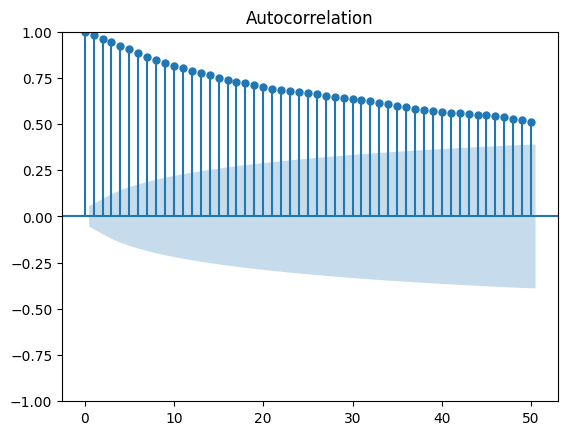

In [ ]:
plot_acf(pm.data['Spread_Close'],lags=50)
plt.show()

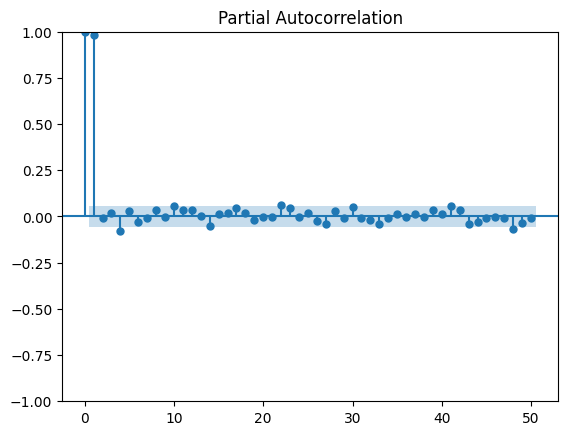

In [135]:
plot_pacf(pm.data['Spread_Close'],lags=50)
plt.show()

In [136]:
result = adfuller(pm.data['Spread_Close'].diff().dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -19.470556
p-value: 0.000000


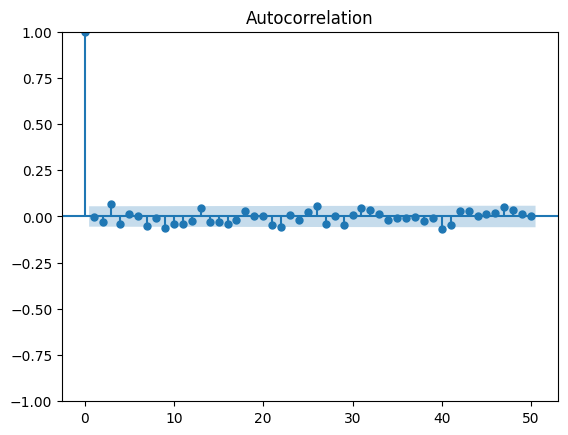

In [137]:
plot_acf(pm.data['Spread_Close'].diff().dropna(),lags=50)
plt.show()

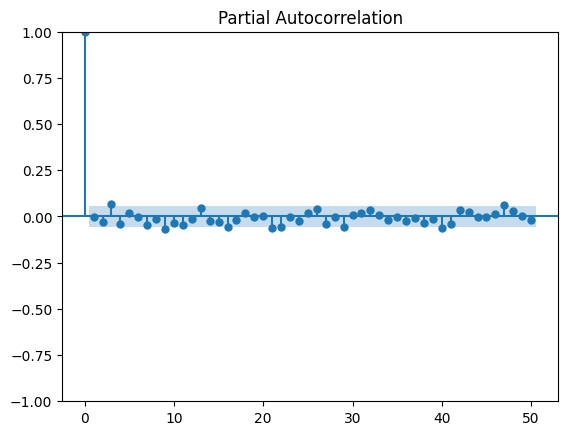

In [138]:
plot_pacf(pm.data['Spread_Close'].diff().dropna(),lags=50)
plt.show()

In [139]:

result = adfuller(pm.data['Spread_Close'].diff().dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -19.470556
p-value: 0.000000
